In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import shap
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the processed dataset
df = pd.read_csv('../data/processed/liver_cancer_recurrence_dataset_10000.csv')

# Define multimodal features (imaging and clinical data) and the target variable
features = [
    'tumor_size_cm', 'tumor_number', 'vascular_invasion_imaging', 
    'afp_ngml', 'cirrhosis_present', 'image_feature_vector_norm', 
    'text_embedding_risk_score', 'multimodal_feature_vector_norm'
]
X = df[features]
y = df['recurrence_within_2yr']

# Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data Scaling (Standardization) - Essential for Deep Neural Networks
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Data Shape: {X_train_scaled.shape}")
print(f"Testing Data Shape: {X_test_scaled.shape}")

Training Data Shape: (8000, 8)
Testing Data Shape: (2000, 8)


In [3]:
# Build the Deep Neural Network Architecture (Hidden Layers: 128 -> 64 -> 32)
dnn_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32), 
    activation='relu', 
    solver='adam', 
    max_iter=500, 
    random_state=42
)

# Train the model
print("Training the Deep Neural Network... Please wait.")
dnn_model.fit(X_train_scaled, y_train)

# Evaluate the model
y_pred = dnn_model.predict(X_test_scaled)
print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

Training the Deep Neural Network... Please wait.

--- Model Evaluation ---
Accuracy: 96.60%

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.95       724
           1       0.98      0.97      0.97      1276

    accuracy                           0.97      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.97      0.97      0.97      2000



Generating SHAP Explanations...


  0%|          | 0/200 [00:00<?, ?it/s]

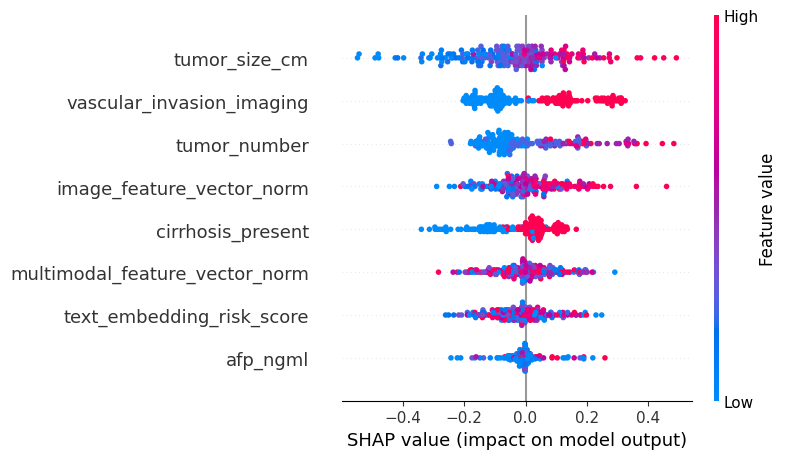

In [4]:
# SHAP Explainability (Optimized for large datasets)
print("Generating SHAP Explanations...")

# Use K-Means to summarize the background data and speed up SHAP calculation
background = shap.kmeans(X_train_scaled, 50)
explainer = shap.KernelExplainer(dnn_model.predict, background)

# Explain the predictions for the first 200 patients in the test set to save computation time
shap_values = explainer.shap_values(X_test_scaled[:200])

# Generate and display the SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test.iloc[:200], feature_names=features)

In [5]:
import os

# Create the models directory if it does not exist
os.makedirs('../models', exist_ok=True)

# Save the trained model and the feature scaler for production deployment
joblib.dump(dnn_model, '../models/liver_cancer_dnn_model.pkl')
joblib.dump(scaler, '../models/feature_scaler.pkl')

print("Model and Scaler successfully saved to the '../models/' folder!")

Model and Scaler successfully saved to the '../models/' folder!
